# Task 1: Distribution Analysis Using Histograms

1. Histograms with 5 bins

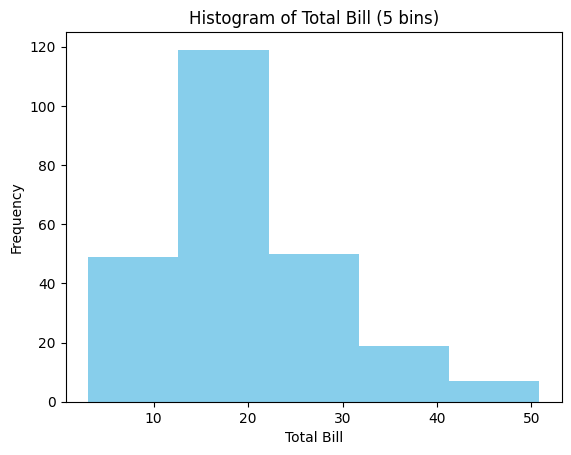

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv")

plt.hist(df['total_bill'], bins=5, color='skyblue')
plt.xlabel('Total Bill')
plt.ylabel('Frequency')
plt.title('Histogram of Total Bill (5 bins)')
plt.show()


2. Histograms with 20 bins

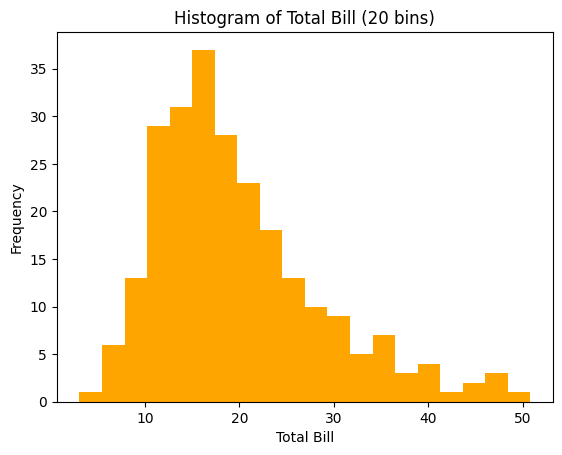

In [3]:

plt.hist(df['total_bill'], bins=20, color='orange')
plt.xlabel('Total Bill')
plt.ylabel('Frequency')
plt.title('Histogram of Total Bill (20 bins)')
plt.show()

1. What does the distribution of total_bill look like — is it symmetric, left-skewed, or right-skewed?

The distribution of total_bill is right-skewed. Most of the values are concentrated in the lower to mid range (around 10–20), while fewer observations extend toward higher values (up to around 50), creating a long tail on the right side.

2. How does changing the number of bins affect your ability to interpret the distribution?

Changing the number of bins affects the level of detail in the histogram. Fewer bins provide a smoother, more general view of the distribution but may hide important patterns, while more bins offer a more detailed view that can reveal finer structure but may introduce noise and make the distribution harder to interpret.

# Task 2: Outlier Detection Using Box Plots

Create side-by-side box plots comparing the distribution of total_bill across the four days (day column: Thur, Fri, Sat, Sun).

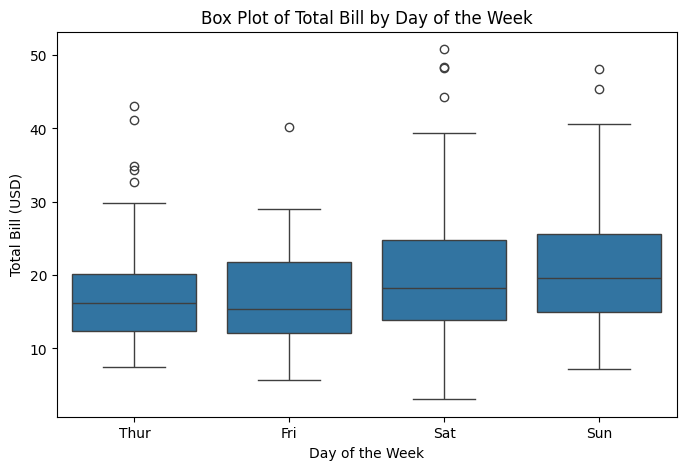

In [4]:
import seaborn as sns
plt.figure(figsize=(8,5))
order = ['Thur', 'Fri', 'Sat', 'Sun']
sns.boxplot(x='day', y='total_bill', data=df, order=order)
plt.xlabel('Day of the Week')
plt.ylabel('Total Bill (USD)')
plt.title('Box Plot of Total Bill by Day of the Week')
plt.show()

1. On which day does the median total bill appear highest?


The median total bill is highest on Sunday, as indicated by the highest median line among all days in the box plot.



2. Identify at least one day that appears to have outliers. Calculate the IQR for that day manually using df.groupby() and quantile(), and verify whether the points you identified qualify as outliers using the standard rule: Q1 − 1.5×IQR and Q3 + 1.5×IQR.

Ans: From above task of box plot it is clear that Day - Saturday has highest outliers.

In [5]:
grouped = df.groupby('day')['total_bill']

Q1 = grouped.quantile(0.25)
Q3 = grouped.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

summary = pd.DataFrame({
    'Q1': Q1,
    'Q3': Q3,
    'IQR': IQR,
    'Lower Bound': lower_bound,
    'Upper Bound': upper_bound
})

print(summary)

sat_lb = lower_bound['Sat']
sat_ub = upper_bound['Sat']

sat_data = df[df['day'] == 'Sat']['total_bill']

outliers = sat_data[(sat_data < sat_lb) | (sat_data > sat_ub)]
print(outliers)

           Q1       Q3      IQR  Lower Bound  Upper Bound
day                                                      
Fri   12.0950  21.7500   9.6550     -2.38750     36.23250
Sat   13.9050  24.7400  10.8350     -2.34750     40.99250
Sun   14.9875  25.5975  10.6100     -0.92750     41.51250
Thur  12.4425  20.1550   7.7125      0.87375     31.72375
59     48.27
102    44.30
170    50.81
212    48.33
Name: total_bill, dtype: float64


# Task 3: Multi-Variable Comparison Using an Interactive Plot

In [6]:
import plotly.express as px

fig = px.scatter(
    df,
    x='total_bill',
    y='tip',
    color='time',  # Lunch vs Dinner
    hover_data=['day', 'size'],
    title='Total Bill vs Tip (Colored by Time)'
)

fig.show()

1. Does there appear to be a relationship between total_bill and tip? Describe what you observe.

There is a positive relationship between total_bill and tip, where higher total bills generally correspond to higher tip amounts.

2. Do Lunch and Dinner transactions differ noticeably in their tipping patterns? What does the color separation reveal?

Dinner transactions tend to have higher total bills and tips compared to lunch, and the spread of values is larger for dinner, indicating more variability in spending and tipping behavior.

3. Identify one specific data point (visible via hover) that you find interesting or unusual, and briefly explain why.

One interesting data point is a transaction with a total bill of around $50 and a tip close to $10. This stands out as it represents one of the highest tips in the dataset and indicates a relatively high tipping percentage compared to other observations.